# Introduction to OpenCV for Materials Data Science

This notebook introduces a simple computer-vision workflow using OpenCV.
The goal is to understand how an image can be treated as **numerical data** and progressively transformed into measurable objects.

### Workflow

**Image → pixel array → colour channels → grayscale → crop → threshold → contours → object extraction**

Although cats are unlikely to be materials data, the same workflow can be applied to materials-science images such as particles, pores, grains, inclusions, cracks, and surface defects.

## 1. Import the required libraries

- **OpenCV (`cv2`)**: image processing and computer vision
- **NumPy**: numerical array operations
- **Pandas**: tabular data handling
- **Matplotlib**: plotting and image visualization

An image loaded by OpenCV is represented internally as a **NumPy array**.


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load an image

`cv2.imread()` reads an image from disk and converts it into an array of pixel values.

For a colour image, the array normally has the shape

$
(\text{height},\ \text{width},\ 3)
$

where the final dimension contains the three colour channels.

`cv2.imshow()` opens the image in an OpenCV window. `cv2.waitKey(0)` keeps that window open until a key is pressed.


In [2]:
image = cv2.imread('Cats_image.jpeg')          # load the image
print(image)                                   # image as an array

# Show the image in a window, then close the window on any keypress
cv2.imshow('original', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[[27 66 41]
  [18 54 30]
  [10 47 21]
  ...
  [25 63 33]
  [43 84 52]
  [55 96 64]]

 [[20 56 32]
  [ 9 45 21]
  [ 2 39 13]
  ...
  [25 64 32]
  [43 85 50]
  [55 97 62]]

 [[ 6 42 18]
  [ 0 32  8]
  [ 0 32  6]
  ...
  [29 69 34]
  [42 85 48]
  [50 93 56]]

 ...

 [[ 4 11  4]
  [ 4 11  4]
  [ 4 11  4]
  ...
  [ 2 27 13]
  [ 4 31 15]
  [ 5 32 16]]

 [[ 1  5  0]
  [ 1  5  0]
  [ 2  6  0]
  ...
  [ 3 28 14]
  [ 4 31 15]
  [ 3 32 16]]

 [[ 0  2  0]
  [ 0  2  0]
  [ 1  3  0]
  ...
  [ 4 29 15]
  [ 3 32 16]
  [ 3 32 16]]]


## 3. BGR versus RGB

OpenCV conventionally loads colour images in **BGR** order:

$[B,\ G,\ R]$

Matplotlib expects **RGB** order:

$[R,\ G,\ B]$

Therefore, an OpenCV image should normally be converted before displaying it with `plt.imshow()`.

```python
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
```

Without this conversion, red and blue appear swapped.


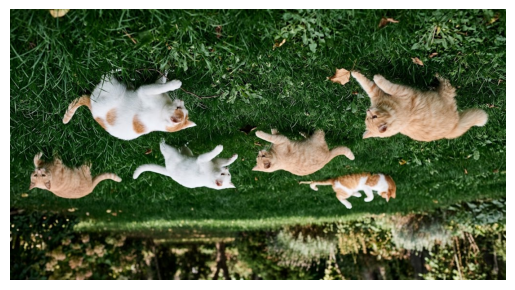

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  #changing the channels since cv2 loads BGR but plt expects RGB

plt.imshow(image_rgb)
#plt.imshow(image)                                  #BLUE CATS !
plt.axis('off')
plt.show()

## 4. Geometric transformations

OpenCV also provides simple geometric operations such as rotation, resizing, translation, and flipping.

Here the image is rotated by \(180^\circ\).

Geometric transformations are useful in materials imaging when samples or micrographs need to be brought into a common orientation before quantitative analysis.


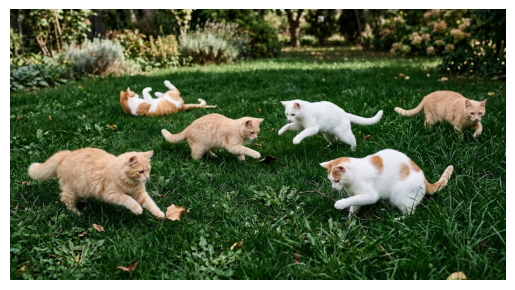

In [6]:
image = cv2.rotate(image_rgb, cv2.ROTATE_180)
plt.imshow(image)
plt.axis('off')
plt.show()

## 5. Colour channels

A colour image can be thought of as three 2D intensity maps stacked together.

Each channel contains the intensity associated with one colour component at every pixel.

$I(x,y) = [R(x,y),G(x,y),B(x,y)]$

`cv2.split()` separates these channels so that they can be examined individually.

> **Important:** the appearance of a channel plot depends on the Matplotlib colour map used. The underlying channel is still only a 2D matrix of intensity values.


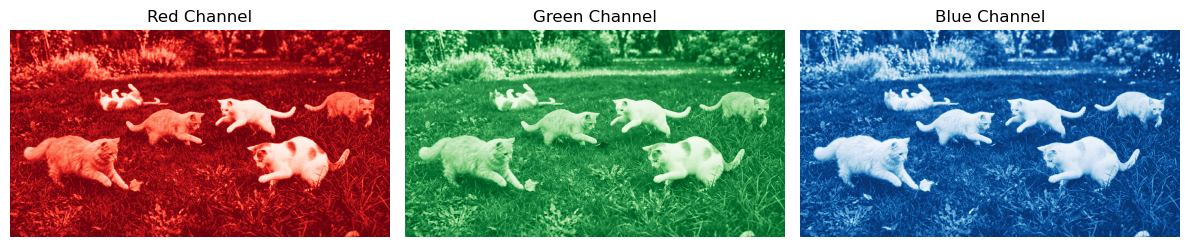

In [7]:
B, G, R = cv2.split(image)
image_greyscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap = 'Reds_r')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(G, cmap = 'Greens_r')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(B, cmap = 'Blues_r')
plt.title('Blue Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Grayscale representation

A grayscale image contains only **one intensity value per pixel** rather than three colour values.

This reduces an image from

$
H \times W \times 3
$

to

$
H \times W
$

and is commonly used before classical image-processing operations such as thresholding and contour detection.

### QUESTION :  Why are we using `gray_r` instead of `grey`?


Text(0.5, 1.0, 'greyscaled')

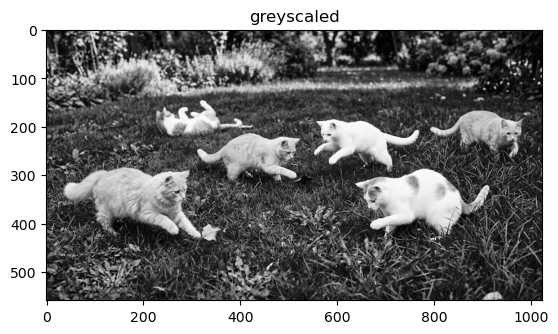

In [12]:
plt.imshow(image_greyscale, cmap = "Greys_r")  
plt.title("greyscaled")

## 7. Crop to a region of interest

Often only part of an image is relevant to the analysis. Cropping removes unwanted regions and reduces the amount of data that must be processed.

NumPy image slicing follows:

```python
image[y_start:y_end, x_start:x_end]
```

Notice that NumPy uses **row, column**, which corresponds to **y, x** in image coordinates.

Here, rows 120 to 449 are retained while the full image width is preserved.


Text(0.5, 1.0, 'greyscaled')

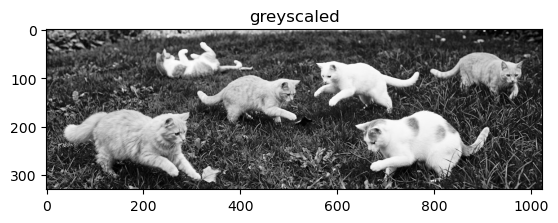

In [14]:
#crop the image to isolate area with cats

image_cropped = image_greyscale[120:450, :]
plt.imshow(image_cropped, cmap = "Greys_r")
plt.title("greyscaled")

## 8. Thresholding: from intensities to a binary mask

Thresholding converts a grayscale image into two classes: **foreground** and **background**.

For a threshold \(T\),

$
B(x,y)=
\begin{cases}
255, & I(x,y)>T\\
0, & I(x,y)\leq T
\end{cases}
$

The resulting binary image is no longer intended to look realistic. It is a **segmentation mask**.

In this example, the brighter cats become large foreground regions, while parts of the textured grass also become foreground noise.


Total contours: 2246


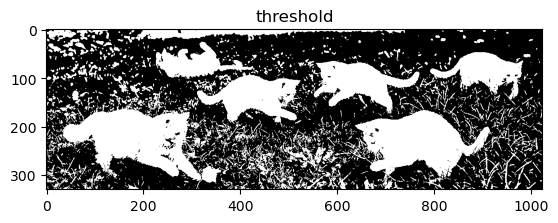

In [17]:
#thresholding and contouring

_, image_thresh = cv2.threshold(image_cropped, 75, 255, cv2.THRESH_BINARY)
plt.imshow(image_thresh, cmap = "Greys_r")    #why reversed ?
plt.title("threshold")

# Find contours
contours, _ = cv2.findContours(
    image_thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE)

print("Total contours:", len(contours))

## 9. Contours and object candidates

A **contour** is a sequence of points describing the boundary of a connected region in the binary image.

`cv2.findContours()` identifies these boundaries.

Because the grass also creates many foreground regions, thresholding alone detects far more objects than just the cats.

One simple strategy is to use **contour area** as a feature and keep only the largest connected regions.

$[
\text{binary pixels} \rightarrow \text{connected regions} \rightarrow \text{candidate objects}
]$


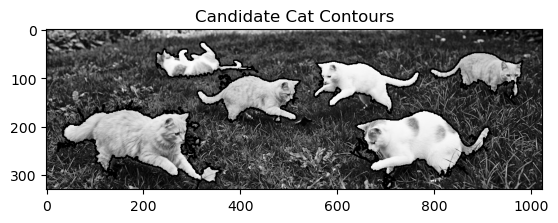

In [21]:
# Sort contours by area, largest first
contours_sorted = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)

image_contoured = image_cropped.copy()

cv2.drawContours(
    image_contoured,
    contours_sorted[:6],
    -1,
    (0, 255, 0),
    2
)


plt.imshow(image_contoured, cmap = 'Greys_r')
plt.title("Candidate Cat Contours")
plt.show()

## 10. Map detected contours back onto the original image

Contours detected in a crop use coordinates relative to the **top-left corner of that crop**.

Because the crop was

```python
image[120:450, :]
```

drawing the contours onto the same region of the original image places them back at the correct spatial location.

This is useful when analysis is performed on a region of interest but the final result needs to be visualized in the context of the full image.


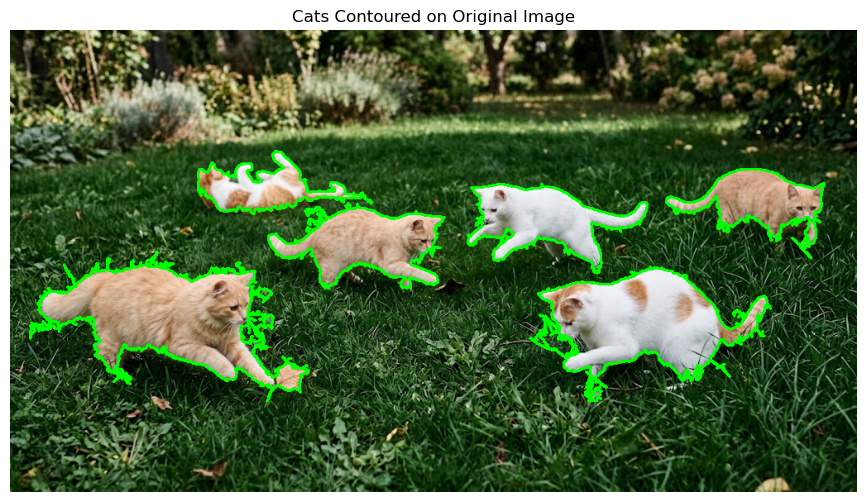

In [22]:
# Draw crop-relative contours onto that region
cv2.drawContours(
    image[120:450, :],                  #adjusting for the y -> shift each contour down by 120, since that was the crop
    contours_sorted[:6],
    -1,
    (0, 255, 0),
    2
)

# Display original image with contours
plt.figure(figsize=(12, 6))
plt.imshow(image)
plt.title("Cats Contoured on Original Image")
plt.axis("off")
plt.show()


---

# Exercise: Improve the segmentation

The first thresholding approach detects the cats, but it also captures substantial texture from the grass.

Try improving the pipeline:

1. Load or reuse the cat image.
2. Apply a **Gaussian blur** to suppress small-scale image texture.
3. Replace the manually selected threshold with **Otsu's automatic thresholding**.
4. Use a $(5\times5)$ morphological kernel to clean the binary mask.
5. Detect the contours again.
6. Compare the resulting cat boundaries with the first attempt.

### Question to consider

How do preprocessing choices change which physical or visual features survive the segmentation?


In [ ]:
# load the image

### Gaussian blurring 
smooths local intensity variations before segmentation.

```python
cv2.GaussianBlur(source, kernel_size, sigmaX)
```

For example:

- `(11, 11)` is the size of the neighborhood used for smoothing.
- `8` is the Gaussian standard deviation along the x direction (`sigmaX`).

The operation is a weighted local average, with pixels near the center receiving greater weight.

In materials imaging, the blur scale should be chosen carefully because excessive smoothing can remove physically meaningful small features.


In [12]:
image_blurred = cv2.GaussianBlur(image_cropped, (11,11), 8)

# _, image_thresh = ?    -> Hint use cv.THRESH_OTSU for better results, and try a few different thresholds values

### Morphological cleanup

Binary masks often contain isolated pixels, rough boundaries, small gaps, or holes.

Morphological operations modify objects according to a **structuring element**, or kernel.

Two useful operations are:

- **Opening:** erosion followed by dilation. Useful for removing small foreground features.
- **Closing:** dilation followed by erosion. Useful for filling small gaps and connecting nearby foreground regions.

Here, a $5\times5$ kernel defines the spatial scale of the cleanup operation.


In [13]:
kernel = np.ones((5, 5), np.uint8)

# Remove small white noise
image_clean = cv2.morphologyEx(image_thresh, cv2.MORPH_OPEN, kernel)

# Fill small gaps inside cats
image_clean = cv2.morphologyEx(image_clean, cv2.MORPH_CLOSE, kernel)

### Compare the image-processing stages

Always inspect intermediate results.

A computer-vision pipeline should not be treated as a black box. Visualizing the grayscale image, threshold mask, and cleaned mask helps determine **where information is being gained or lost**.

This is particularly important in materials science, where an apparently cleaner segmentation is not necessarily a more physically meaningful segmentation.


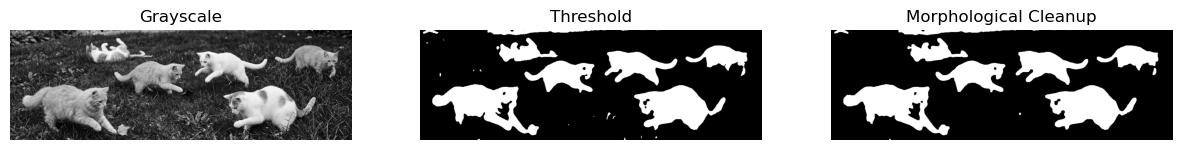

In [14]:
# display the greyscaled, thresholded and cleaned images

### Detect contours after morphology

Contour detection is repeated using the cleaned binary mask.

The expectation is that morphological processing reduces small noisy regions and produces more coherent object boundaries.

The number and areas of the resulting contours can then be compared with the original segmentation.


In [ ]:
# Find contours
contours_morphed, _ = cv2.findContours(
    image_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE)

print("Total contours:", len(contours))

### Visualize the improved object candidates

The largest contours are again selected and mapped onto the image.
At this stage, the image-processing pipeline has converted raw pixel intensities into identifiable **object candidates**.



The same principle can be used for materials-science problems such as:

- particle detection
- pore segmentation
- grain or phase identification
- inclusion detection
- crack or defect analysis

Once objects have been identified, quantitative descriptors such as **area, perimeter, centroid, equivalent diameter, aspect ratio, and circularity** can be extracted and stored in a DataFrame for subsequent statistical analysis or machine learning.


# Take-home message

OpenCV provides a bridge between **image data** and **quantitative data science**.

$
\boxed{
\text{Raw image}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Segmentation}
\rightarrow
\text{Objects}
\rightarrow
\text{Features}
\rightarrow
\text{Data analysis}
}
$

The software does not inherently know what a *cat*, *particle*, *pore*, or *grain* is. Those objects are defined through measurable image properties such as intensity, connectivity, size, shape, texture, and spatial context.

That makes image processing not only a coding task, but also a **measurement-design problem**.
